# **Análisis de Datos Saber 11 - Departamento de Caldas**

Este notebook implementa el proceso de selección, limpieza, alistamiento y análisis exploratorio de los datos de las pruebas Saber 11 para el departamento de Caldas, como parte del Proyecto 2 del curso *Analítica Computacional para la Toma de Decisiones*. El producto final está orientado al **Ministerio de Educación** como usuario final, y busca responder tres preguntas de negocio relacionadas con equidad socioeconómica, desempeño territorial y brechas de género.

## Tarea 2 - Selección, limpieza y alistamiento de datos

Los datos provienen del portal de [Datos Abiertos de Colombia](https://www.datos.gov.co/Educaci-n/Resultados-nicos-Saber-11/kgxf-xxbe), actualizados a abril de 2024. La selección, limpieza y alistamiento de datos ya fue realizada en el Proyecto 1.

## Tarea 3 - Exploración y análisis de datos

Con los datos limpios y correctamente tipados, se realiza un análisis de datos orientado a responder las tres preguntas de negocio que hemos desarrollado. Esto incluye estadísticas descriptivas, histogramas, diagramas de caja, diagramas de dispersión y mapas de calor sobre distintas variables relevantes para el desarrollo de los modelos de redes neuronales en tarea4/.

---

Daniel Benavides - 202220428 

Juanita Cortés - 202222129 

Andrés Felipe Herrera - 202220888

In [4]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import altair as alt
from prettytable import PrettyTable

from matplotlib import font_manager
plt.rcParams['font.family'] = 'Arial'

alt.data_transformers.enable('vegafusion')

DataTransformerRegistry.enable('vegafusion')

In [5]:
import warnings
warnings.filterwarnings('ignore')

## Carga de datos

In [6]:
df = pd.read_csv('../data/caldas_data.csv')

print(f"Filas: {len(df)} | Columnas: {df.shape[1]}")
df.head(5)

Filas: 48058 | Columnas: 23


,periodo,cole_mcpio_ubicacion,cole_depto_ubicacion,punt_matematicas,punt_lectura_critica,punt_global,fami_estratovivienda,fami_educacionmadre,fami_educacionpadre,fami_personashogar,...,fami_tieneautomovil,fami_tienelavadora,punt_c_naturales,punt_sociales_ciudadanas,punt_ingles,cole_naturaleza,cole_area_ubicacion,cole_bilingue,estu_genero,desemp_ingles
0,20224,MANIZALES,CALDAS,64.0,66.0,330.0,Estrato 2,Primaria incompleta,Primaria incompleta,3.0,...,0.0,1.0,64.0,70.0,65.0,Público,URBANO,0.0,M,A2
1,20224,MARQUETALIA,CALDAS,55.0,55.0,256.0,Estrato 2,Secundaria (Bachillerato) completa,NaN,2.0,...,0.0,0.0,50.0,43.0,57.0,Público,RURAL,NaN,F,A1
2,20224,ANSERMA,CALDAS,46.0,46.0,205.0,Estrato 2,Primaria completa,No sabe,3.0,...,0.0,1.0,38.0,34.0,40.0,Público,URBANO,0.0,F,A-
3,20224,MANIZALES,CALDAS,60.0,64.0,297.0,Estrato 3,Secundaria (Bachillerato) completa,Secundaria (Bachillerato) incompleta,3.0,...,0.0,1.0,57.0,57.0,57.0,Privado,URBANO,0.0,M,A1
4,20224,RIOSUCIO,CALDAS,43.0,37.0,210.0,Estrato 2,Primaria incompleta,Primaria incompleta,3.0,...,0.0,0.0,50.0,41.0,34.0,Público,RURAL,0.0,F,A-


## 1. Pregunta de negocio

### *¿Cuál es el puntaje global esperado para un estudiante de Caldas dado su perfil socioeconómico y el tipo de institución educativa?*

## 2. Pregunta de negocio

### *¿Puede identificarse si un estudiante está en riesgo de obtener un puntaje global por debajo del umbral de bajo desempeño, según sus características socioeconómicas y escolares?*

Esta pregunta se responde con un **modelo de clasificación binaria**. La variable objetivo es:

$$\text{bajo\_rendimiento} = \begin{cases} 1 & \text{si } \texttt{punt\_global} < 250 \\ 0 & \text{en otro caso} \end{cases}$$

El umbral de 250 puntos es consistente con el análisis del Proyecto 1, donde se identificó ese valor como frontera entre municipios de rendimiento crítico y rendimiento medio-alto.

### 2.1 Feature Engineering

In [7]:
UMBRAL_BAJO = 230

# --- Target variable ---
# Se define la variable objetivo como clasificación binaria
# Se eliminan filas sin punt_global ya que es indispensable para el target

df = df.dropna(subset=['punt_global'])
df['bajo_rendimiento'] = (df['punt_global'] < UMBRAL_BAJO).astype(int)

print(f"Distribución del target:\n{df['bajo_rendimiento'].value_counts()}")
print(f"\n% bajo rendimiento: {df['bajo_rendimiento'].mean():.1%}")

Distribución del target:
bajo_rendimiento
0    31891
1    16167
Name: count, dtype: int64

% bajo rendimiento: 33.6%


In [8]:
# --- Estrato: ordinal numérico 1-6 ---
# El P1 mostró que el estrato tiene efecto progresivo y monotónico sobre el puntaje,
# por lo que es apropiado tratarlo como ordinal numérico en lugar de dummies.
estrato_map = {
    'Estrato 1': 1, 'Estrato 2': 2, 'Estrato 3': 3,
    'Estrato 4': 4, 'Estrato 5': 5, 'Estrato 6': 6
}
df['estrato_num'] = df['fami_estratovivienda'].map(estrato_map)

# --- Educación de los padres: ordinal numérico ---
# El P1 mostró un gradiente continuo: a mayor educación, mayor puntaje.
# Asignamos un entero que preserva el orden natural del nivel educativo.
# 'No sabe' / 'No aplica' → NaN para no introducir ruido.
edu_map = {
    'Ninguno': 0,
    'Primaria incompleta': 1,
    'Primaria completa': 2,
    'Secundaria (Bachillerato) incompleta': 3,
    'Secundaria (Bachillerato) completa': 4,
    'Técnica o tecnológica incompleta': 5,
    'Técnica o tecnológica completa': 6,
    'Educación profesional incompleta': 7,
    'Educación profesional completa': 8,
    'Postgrado': 9,
}

df['edu_madre_num'] = df['fami_educacionmadre'].map(edu_map)   # NaN si 'No sabe'/'No aplica'
df['edu_padre_num'] = df['fami_educacionpadre'].map(edu_map)

# --- Índice de activos del hogar (0-4) ---
# Creado en P1. Si no existe, se recalcula.
asset_cols = ['fami_tienecomputador', 'fami_tieneinternet',
              'fami_tieneautomovil', 'fami_tienelavadora']
if 'indice_activos' not in df.columns:
    df['indice_activos'] = df[asset_cols].sum(axis=1, skipna=True)

# --- Variables escolares binarias ---
# cole_naturaleza: Público → 0, Privado → 1
df['es_privado'] = (df['cole_naturaleza'] == 'Privado').astype(float)
df.loc[df['cole_naturaleza'].isna(), 'es_privado'] = np.nan

# cole_area_ubicacion: RURAL → 0, URBANO → 1
df['es_urbano'] = (df['cole_area_ubicacion'] == 'URBANO').astype(float)
df.loc[df['cole_area_ubicacion'].isna(), 'es_urbano'] = np.nan

# --- Género: M → 1, F → 0 ---
df['genero_num'] = df['estu_genero'].map({'M': 1, 'F': 0})

In [9]:
# Definir el conjunto de features que usará el modelo

FEATURES = [
    'estrato_num',
    'edu_madre_num',
    'edu_padre_num',
    'indice_activos',
    'fami_tienecomputador',
    'fami_tieneinternet',
    'fami_tieneautomovil',
    'fami_tienelavadora',
    'es_privado',
    'es_urbano',
    'genero_num',
]

TARGET = 'bajo_rendimiento'

df_model = df[FEATURES + [TARGET]].copy()
print(f"Shape del dataset de modelamiento: {df_model.shape}")
df_model.head(3)

Shape del dataset de modelamiento: (48058, 12)


,estrato_num,edu_madre_num,edu_padre_num,indice_activos,fami_tienecomputador,fami_tieneinternet,fami_tieneautomovil,fami_tienelavadora,es_privado,es_urbano,genero_num,bajo_rendimiento
0,2,1.0,1.0,3.0,1.0,1.0,0.0,1.0,0.0,1.0,1.0,0
1,2,4.0,NaN,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0
2,2,2.0,NaN,2.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1


### 2.2 Datos faltantes

In [10]:
missing = df_model.isnull().mean().sort_values(ascending=False) * 100
missing_table = PrettyTable()
missing_table.field_names = ["Feature", "% Faltante"]
for col, pct in missing.items():
    missing_table.add_row([col, f"{pct:.2f}%"])
print(missing_table)

+----------------------+------------+
|       Feature        | % Faltante |
+----------------------+------------+
|    edu_padre_num     |   7.82%    |
|    edu_madre_num     |   1.87%    |
| fami_tieneautomovil  |   0.71%    |
| fami_tienecomputador |   0.64%    |
|  fami_tienelavadora  |   0.59%    |
|  fami_tieneinternet  |   0.13%    |
|      genero_num      |   0.12%    |
|     estrato_num      |   0.00%    |
|    indice_activos    |   0.00%    |
|      es_privado      |   0.00%    |
|      es_urbano       |   0.00%    |
|   bajo_rendimiento   |   0.00%    |
+----------------------+------------+


### 2.3 Analysis

In [11]:
# Estrato vs bajo_rendimiento

estrato_risk = (
    df_model.dropna(subset=['estrato_num'])
    .groupby('estrato_num')[TARGET]
    .mean()
    .reset_index()
    .rename(columns={TARGET: 'tasa_riesgo'})
)

estrato_risk['estrato_num'] = estrato_risk['estrato_num'].astype(str)

chart_estrato = alt.Chart(estrato_risk).mark_bar().encode(
    x=alt.X('estrato_num:O', title='Estrato', axis=alt.Axis(labelAngle=0)),
    y=alt.Y('tasa_riesgo:Q', title='Tasa de bajo rendimiento', axis=alt.Axis(format='%')),
    color=alt.Color('tasa_riesgo:Q', scale=alt.Scale(scheme='reds'), legend=None)
).properties(
    width=350, height=280,
    title='Tasa de bajo rendimiento por estrato socioeconómico'
)

chart_estrato

alt.Chart(...)

In [12]:
# Índice de activos vs tasa de riesgo.
# El P1 confirmó que a mayor índice de activos, mayor puntaje.

activos_risk = (
    df_model.dropna(subset=['indice_activos'])
    .groupby('indice_activos')[TARGET]
    .mean()
    .reset_index()
    .rename(columns={TARGET: 'tasa_riesgo'})
)
activos_risk['indice_activos'] = activos_risk['indice_activos'].astype(str)

chart_activos = alt.Chart(activos_risk).mark_bar().encode(
    x=alt.X('indice_activos:O', title='Índice de activos del hogar (0 = ninguno, 4 = todos)',
            axis=alt.Axis(labelAngle=0)),
    y=alt.Y('tasa_riesgo:Q', title='Tasa de bajo rendimiento', axis=alt.Axis(format='%')),
    color=alt.Color('tasa_riesgo:Q', scale=alt.Scale(scheme='reds'), legend=None)
).properties(
    width=350, height=280,
    title='Tasa de bajo rendimiento por índice de activos del hogar'
)

chart_activos

alt.Chart(...)

In [13]:
# Educación de la madre vs tasa de riesgo

edu_risk = (
    df_model.dropna(subset=['edu_madre_num'])
    .groupby('edu_madre_num')[TARGET]
    .mean()
    .reset_index()
    .rename(columns={TARGET: 'tasa_riesgo'})
)

edu_labels = {
    0: 'Ninguno', 1: 'Prim. inc.', 2: 'Prim. comp.',
    3: 'Sec. inc.', 4: 'Sec. comp.', 5: 'Téc. inc.',
    6: 'Téc. comp.', 7: 'Prof. inc.', 8: 'Prof. comp.', 9: 'Postgrado'
}
edu_risk['nivel'] = edu_risk['edu_madre_num'].map(edu_labels)

chart_edu = alt.Chart(edu_risk).mark_bar().encode(
    x=alt.X('edu_madre_num:O', title='Nivel educativo de la madre',
            axis=alt.Axis(labelExpr="{'0':'Ninguno','1':'Prim.inc','2':'Prim.comp','3':'Sec.inc','4':'Sec.comp','5':'Téc.inc','6':'Téc.comp','7':'Prof.inc','8':'Prof.comp','9':'Postgrado'}[datum.label]",
                          labelAngle=-35)),
    y=alt.Y('tasa_riesgo:Q', title='Tasa de bajo rendimiento', axis=alt.Axis(format='%')),
    tooltip=['nivel:N', alt.Tooltip('tasa_riesgo:Q', format='.1%')],
    color=alt.Color('tasa_riesgo:Q', scale=alt.Scale(scheme='reds'), legend=None)
).properties(
    width=400, height=280,
    title='Tasa de bajo rendimiento por nivel educativo de la madre'
)

chart_edu

alt.Chart(...)

In [14]:
# Naturaleza del colegio y zona vs tasa de riesgo.
# El P1 mostró que privado > público en puntaje, y que la brecha rural-urbana no es uniforme

def tasa_por_binaria(col, label_0, label_1):
    tmp = (
        df_model.dropna(subset=[col])
        .groupby(col)[TARGET].mean()
        .reset_index()
        .rename(columns={col: 'valor', TARGET: 'tasa_riesgo'})
    )
    tmp['etiqueta'] = tmp['valor'].map({0.0: label_0, 1.0: label_1})
    return tmp

df_priv = tasa_por_binaria('es_privado', 'Público', 'Privado')
df_urb  = tasa_por_binaria('es_urbano', 'Rural', 'Urbano')

def bar_binaria(data, titulo):
    return alt.Chart(data).mark_bar().encode(
        x=alt.X('etiqueta:N', title='', axis=alt.Axis(labelAngle=0)),
        y=alt.Y('tasa_riesgo:Q', title='Tasa de bajo rendimiento', axis=alt.Axis(format='%')),
        color=alt.Color('tasa_riesgo:Q', scale=alt.Scale(scheme='reds'), legend=None)
    ).properties(width=200, height=260, title=titulo)

(bar_binaria(df_priv, 'Público vs Privado') | bar_binaria(df_urb, 'Rural vs Urbano'))

alt.HConcatChart(...)

### 2.4 Correlación de features con el target

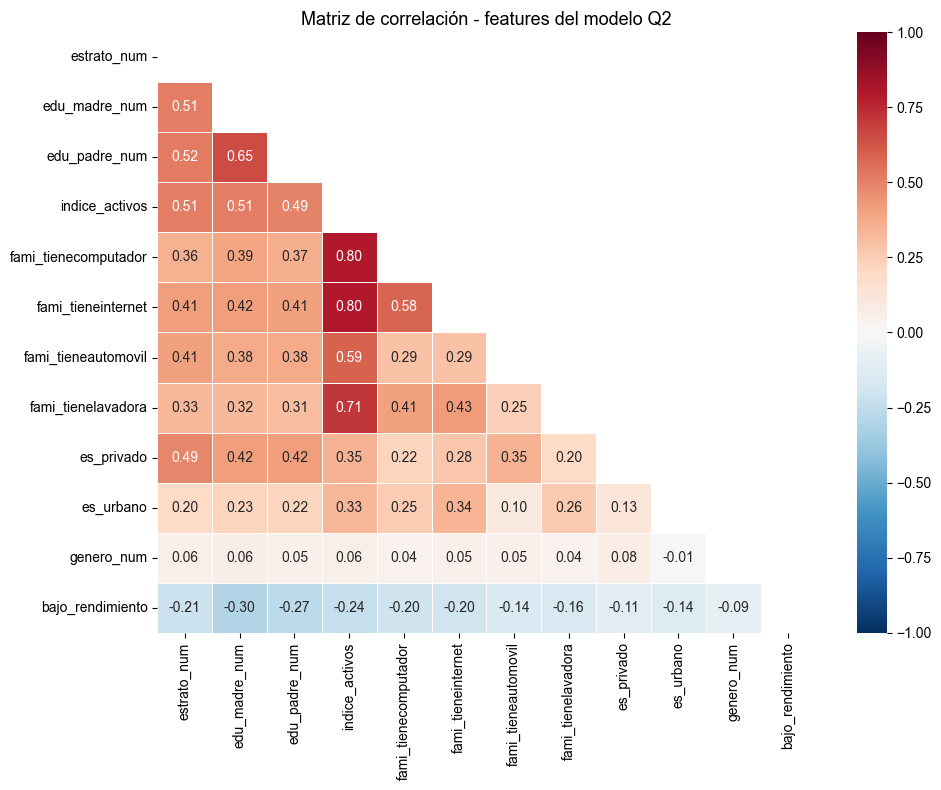

In [15]:
# Mapa de calor de correlaciones entre todos los features

corr_matrix = df_model.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.5, ax=ax
)
ax.set_title('Matriz de correlación - features del modelo Q2', fontsize=13)
plt.tight_layout()
plt.show()

## 3. Pregunta de negocio

### *¿Puede predecirse el nivel de desempeño en inglés de un estudiante (A−, A1, A2, B1, B+) a partir de su perfil académico, socioeconómico y de género?*

### 3.1 Feature Enginnering

In [16]:
# Variable objetivo: nivel de desempeño en inglés
TARGET_P3 = 'desemp_ingles'

# Eliminar filas sin target
df_p3 = df.dropna(subset=[TARGET_P3]).copy()

# Mantener únicamente las categorías esperadas
niveles_ingles = ['A-', 'A1', 'A2', 'B1', 'B+']
df_p3 = df_p3[df_p3[TARGET_P3].isin(niveles_ingles)]

print("Distribución del target:")
print(df_p3[TARGET_P3].value_counts())

print("\nDistribución porcentual:")
print((df_p3[TARGET_P3].value_counts(normalize=True) * 100).round(2))

Distribución del target:
desemp_ingles
A-    22378
A1    15922
A2     6030
B1     2803
B+      924
Name: count, dtype: int64

Distribución porcentual:
desemp_ingles
A-    46.57
A1    33.13
A2    12.55
B1     5.83
B+     1.92
Name: proportion, dtype: float64


### 3.2 Variables Relevantes

In [17]:
# Variables académicas
academic_features = [
    'punt_matematicas',
    'punt_lectura_critica',
    'punt_c_naturales',
    'punt_sociales_ciudadanas']

# Variables socioeconómicas
socioeconomic_features = [
    'estrato_num',
    'edu_madre_num',
    'edu_padre_num',
    'indice_activos',
    'fami_tienecomputador',
    'fami_tieneinternet',
    'fami_tieneautomovil',
    'fami_tienelavadora']

# Variable de género
gender_features = [
    'genero_num'
]

# Variables escolares opcionales
school_features = [
    'es_privado',
    'es_urbano',
    'cole_bilingue']

FEATURES_P3 = academic_features + socioeconomic_features + gender_features + school_features

df_model_p3 = df_p3[FEATURES_P3 + [TARGET_P3]].copy()

print(f"Shape del dataset de modelamiento P3: {df_model_p3.shape}")
df_model_p3.head()

Shape del dataset de modelamiento P3: (48057, 17)


,punt_matematicas,punt_lectura_critica,punt_c_naturales,punt_sociales_ciudadanas,estrato_num,edu_madre_num,edu_padre_num,indice_activos,fami_tienecomputador,fami_tieneinternet,fami_tieneautomovil,fami_tienelavadora,genero_num,es_privado,es_urbano,cole_bilingue,desemp_ingles
0,64.0,66.0,64.0,70.0,2,1.0,1.0,3.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,A2
1,55.0,55.0,50.0,43.0,2,4.0,NaN,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,NaN,A1
2,46.0,46.0,38.0,34.0,2,2.0,NaN,2.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,A-
3,60.0,64.0,57.0,57.0,3,4.0,3.0,3.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,A1
4,43.0,37.0,50.0,41.0,2,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,A-


### 3.3 Datos Faltantes

In [18]:
missing_p3 = df_model_p3.isnull().mean().sort_values(ascending=False) * 100

missing_table_p3 = PrettyTable()
missing_table_p3.field_names = ["Feature", "% Faltante"]

for col, pct in missing_p3.items():
    missing_table_p3.add_row([col, f"{pct:.2f}%"])

print(missing_table_p3)

+--------------------------+------------+
|         Feature          | % Faltante |
+--------------------------+------------+
|      cole_bilingue       |   9.49%    |
|      edu_padre_num       |   7.82%    |
|      edu_madre_num       |   1.87%    |
|   fami_tieneautomovil    |   0.71%    |
|   fami_tienecomputador   |   0.64%    |
|    fami_tienelavadora    |   0.59%    |
|    fami_tieneinternet    |   0.13%    |
|        genero_num        |   0.12%    |
|        es_urbano         |   0.00%    |
|        es_privado        |   0.00%    |
|     punt_matematicas     |   0.00%    |
|   punt_lectura_critica   |   0.00%    |
|      indice_activos      |   0.00%    |
|       estrato_num        |   0.00%    |
| punt_sociales_ciudadanas |   0.00%    |
|     punt_c_naturales     |   0.00%    |
|      desemp_ingles       |   0.00%    |
+--------------------------+------------+


### 3.4 Analysis

In [19]:
target_dist = (
    df_model_p3[TARGET_P3]
    .value_counts()
    .reindex(niveles_ingles)
    .reset_index()
)

target_dist.columns = ['nivel_ingles', 'conteo']
target_dist['porcentaje'] = target_dist['conteo'] / target_dist['conteo'].sum()

chart_target = alt.Chart(target_dist).mark_bar().encode(
    x=alt.X('nivel_ingles:O', title='Nivel de desempeño en inglés', sort=niveles_ingles),
    y=alt.Y('conteo:Q', title='Número de estudiantes'),
    tooltip=[
        alt.Tooltip('nivel_ingles:N', title='Nivel'),
        alt.Tooltip('conteo:Q', title='Estudiantes'),
        alt.Tooltip('porcentaje:Q', title='Porcentaje', format='.1%')
    ]
).properties(
    width=450,
    height=300,
    title='Distribución del nivel de desempeño en inglés'
)

chart_target

alt.Chart(...)

In [20]:
academic_summary = (
    df_p3
    .groupby(TARGET_P3)[academic_features + ['punt_global']]
    .mean()
    .reindex(niveles_ingles)
    .reset_index()
)

academic_summary

,desemp_ingles,punt_matematicas,punt_lectura_critica,punt_c_naturales,punt_sociales_ciudadanas,punt_global
0,A-,44.332559,46.693672,45.258826,43.715837,223.502771
1,A1,51.673596,52.895742,51.812963,50.679060,259.053888
2,A2,59.408955,59.735158,58.749585,57.793864,295.793201
3,B1,66.425615,65.092401,65.021762,64.465216,329.351052
4,B+,72.215368,69.387446,70.121212,69.679654,357.764069


In [22]:
estrato_ingles = (
    df_p3
    .dropna(subset=['fami_estratovivienda'])
    .groupby(['fami_estratovivienda', TARGET_P3])
    .size()
    .reset_index(name='conteo')
)

estrato_ingles['porcentaje'] = (
    estrato_ingles
    .groupby('fami_estratovivienda')['conteo']
    .transform(lambda x: x / x.sum())
)

chart_estrato_ingles = alt.Chart(estrato_ingles).mark_bar().encode(
    x=alt.X('fami_estratovivienda:O', title='Estrato socioeconómico'),
    y=alt.Y('porcentaje:Q', title='Porcentaje', axis=alt.Axis(format='%')),
    color=alt.Color(f'{TARGET_P3}:N', title='Nivel inglés', sort=niveles_ingles),
    tooltip=[
        alt.Tooltip('fami_estratovivienda:N', title='Estrato'),
        alt.Tooltip(f'{TARGET_P3}:N', title='Nivel inglés'),
        alt.Tooltip('porcentaje:Q', title='Porcentaje', format='.1%'),
        alt.Tooltip('conteo:Q', title='Estudiantes')
    ]
).properties(
    width=600,
    height=350,
    title='Distribución del nivel de inglés por estrato socioeconómico'
)

chart_estrato_ingles

alt.Chart(...)

In [23]:
genero_ingles = (
    df_p3
    .dropna(subset=['estu_genero'])
    .groupby(['estu_genero', TARGET_P3])
    .size()
    .reset_index(name='conteo')
)

genero_ingles['porcentaje'] = (
    genero_ingles
    .groupby('estu_genero')['conteo']
    .transform(lambda x: x / x.sum())
)

chart_genero_ingles = alt.Chart(genero_ingles).mark_bar().encode(
    x=alt.X('estu_genero:N', title='Género'),
    y=alt.Y('porcentaje:Q', title='Porcentaje', axis=alt.Axis(format='%')),
    color=alt.Color(f'{TARGET_P3}:N', title='Nivel inglés', sort=niveles_ingles),
    tooltip=[
        alt.Tooltip('estu_genero:N', title='Género'),
        alt.Tooltip(f'{TARGET_P3}:N', title='Nivel inglés'),
        alt.Tooltip('porcentaje:Q', title='Porcentaje', format='.1%'),
        alt.Tooltip('conteo:Q', title='Estudiantes')
    ]
).properties(
    width=350,
    height=300,
    title='Distribución del nivel de inglés por género'
)

chart_genero_ingles

alt.Chart(...)

In [ ]:
# Codificación solo para análisis exploratorio
ingles_ord_map = {
    'A-': 0,
    'A1': 1,
    'A2': 2,
    'B1': 3,
    'B+': 4
}

df_model_p3['ingles_ord'] = df_model_p3[TARGET_P3].map(ingles_ord_map)

corr_p3 = (
    df_model_p3
    .drop(columns=[TARGET_P3])
    .corr(numeric_only=True)['ingles_ord']
    .sort_values(ascending=False)
    .drop('ingles_ord')
)

corr_p3

punt_c_naturales            0.630420
punt_matematicas            0.619197
punt_lectura_critica        0.615858
punt_sociales_ciudadanas    0.604214
edu_madre_num               0.446485
edu_padre_num               0.440652
estrato_num                 0.422860
indice_activos              0.361657
es_privado                  0.331159
fami_tieneinternet          0.302184
fami_tieneautomovil         0.284646
fami_tienecomputador        0.273676
cole_bilingue               0.218172
fami_tienelavadora          0.211501
es_urbano                   0.138419
genero_num                  0.083505
Name: ingles_ord, dtype: float64

In [25]:
corr_p3_df = corr_p3.reset_index()
corr_p3_df.columns = ['feature', 'correlacion']

chart_corr_p3 = alt.Chart(corr_p3_df).mark_bar().encode(
    x=alt.X('correlacion:Q', title='Correlación con nivel de inglés codificado'),
    y=alt.Y('feature:N', title='Variable', sort='-x'),
    tooltip=[
        alt.Tooltip('feature:N', title='Variable'),
        alt.Tooltip('correlacion:Q', title='Correlación', format='.2f')
    ]
).properties(
    width=550,
    height=400,
    title='Relación de variables numéricas con el nivel de inglés'
)

chart_corr_p3

alt.Chart(...)